# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Lucie Klingens
* Username: lklingens
* Student number: s6390366
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

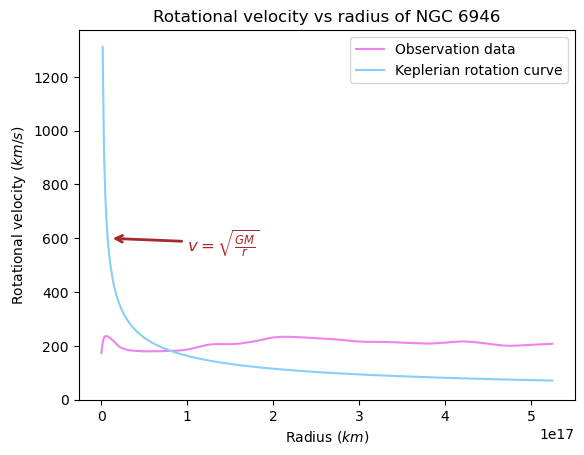

In [2]:
import os
import numpy as np
from pathlib import Path  # Import Path from pathlib so a path can be used on all OS.
from matplotlib import pyplot as plt
from scipy.constants import G  # Import Newtonian constant of gravitation (in m^3 kg^-1 s^-2).
from math import sqrt

# Path definition so the program can find the file

tilde_path = os.path.expanduser('~')  # Makes Python recognize ~ as a sign for the root. 
OSpath = f"{tilde_path}/PROGNUM-repo/Task5/TXT_files/rotcur.dat.txt"
path = Path(OSpath)

radius, rot_velocity = np.loadtxt(path, unpack=True, comments="#")  # Unpack enables unpacking the data from the file into two arrays: radius and rot_velocity.
radii = radius*3.0857e16 # Convert radii from kpc to km

# Create line plot.

plt.plot(radii, rot_velocity, color='violet', label="Observation data")  # Plot rot_velocity (km/s) vs radii(km)
plt.title("Rotational velocity vs radius of NGC 6946")
plt.xlabel("Radius ($km$)")
plt.ylabel("Rotational velocity ($km/s$)")

# Calculate the Keplerian rotation curve.

M_star = 2e10  # Stellar mass of NGC 6946 (in solar masses)
M = M_star*1.9885e30  # Convert to kg
grav_cons = G/1e9  # Convert G to km^3 kg^-1 s^-2
v_kepler = [sqrt((grav_cons*M)/(r)) for r in radii[1:]]  # Calculate v_kepler for all radii in radius, except the first one which is zero (will give an error).
np.savetxt("keplerian_curve.txt", v_kepler, fmt='%.18e', delimiter=' ', newline='\n', header='', footer='', comments='# ')  # Save array to file on disk.

keplerian = np.loadtxt(f"{tilde_path}/PROGNUM-repo/Task5/keplerian_curve.txt")  # Load data into array.

plt.plot(radii[1:], keplerian, color='lightskyblue', label="Keplerian rotation curve")
plt.ylim(bottom=0) #top=np.max(keplerian))
plt.annotate(r'$v=\sqrt{\frac{GM}{r}}$', xy=(0.1e17, 600), xytext=(1e17, 550), color='brown', fontsize=12, arrowprops=dict(arrowstyle='->', color='brown', lw=2))

plt.legend()
plt.show()

Observation:

The Keplerian rotation curve has a steep decline, then gradually descents toward a constant velocity the more the radius increases. The observed data does not follow the shape of the Keplerian curve exactly, but it does have a slight increase in the beginning, then decreases towards a more or less constant rotational velocity. However, the theoretical Kepelerian velocities are a lot larger than the observed velocities and the observed data have a lot of notable fluctuations.

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

The mean and standard deviation I got for the slice are what I expected. The mean is close to 0 and the standard deviation is close to 1.0, which is what I entered in the random samples for the normal distribution.

The distribution in the second plot should be a normal distribution plot, or at least look similar to a normal distribution.

The mean of the piece is: 0.007036732254183497 and the standard deviation of the piece is: 1.0097801279186223.


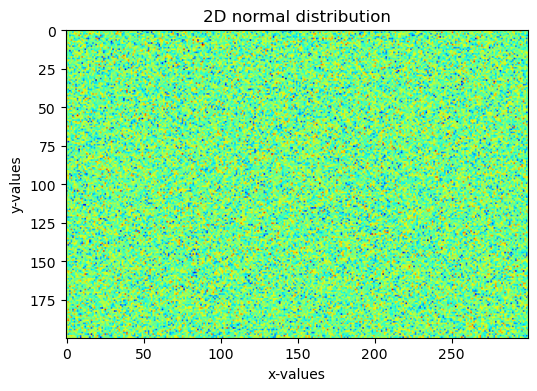

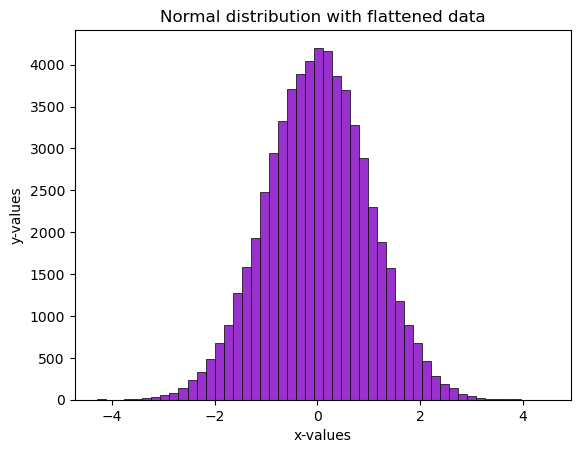

In [4]:
import numpy as np
from matplotlib import pyplot as plt

array = np.random.normal(0, 1.0, 60000)
array_2D = array.reshape(200, 300)  # Reshape into 200 rows, 300 columns

plt.figure(figsize=(8,4))  # Set figure size to w=8 inch, h=4 inch.
plt.imshow(array_2D, cmap='jet')

# Plot title and labels of plot 1

plt.title("2D normal distribution")
plt.xlabel("x-values")
plt.ylabel("y-values")

piece = array_2D[120:151, 256:287]  # 30x30 pixel slice
p_mean = np.mean(piece)
p_stdev = np.std(piece)
print(f"The mean of the piece is: {p_mean} and the standard deviation of the piece is: {p_stdev}.")

array_flat = array_2D.flat  # Make the 2D array flat, using np.flat to not overload the kernel.
plt.figure()  # Plots figure below the first plot
plt.hist(array_flat, bins=50, color='darkorchid', edgecolor='black', linewidth=0.5)

# Plot title and labels of plot 2

plt.title("Normal distribution with flattened data")
plt.xlabel("x-values")
plt.ylabel("y-values")

plt.show()

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

In [6]:
from matplotlib.patches import Ellipse
from math import pi, sqrt

class AstroEllipse(Ellipse):
    """Converts astronomical ellipse atributes to mathmatical elliple attributes"""
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # Save these as attributes so the rest of the class can see them.
        self.xc = xc
        self.yc = yc
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.pa = position_angle
        
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)
        angle_mpl = position_angle
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
        """A function that calculates the area of an ellipse using the objects parameters"""
        a = pi*self.semi_major*self.semi_minor
        return a   
    def perimeter(self):
        """A function that calculates the perimeter using the objects parameters"""
        a, b = self.semi_major, self.semi_minor
        p = pi*(3*(a+b) - sqrt((3*a+b)*(a+3*b)))
        return p
    def __str__(self):
        """A function that returns the objects parameters as a string"""
        s = (f"Ellipse parameters \n"  #\n to start next part on a new line.
        "--------------------\n"
        f"The center: ({self.xc}, {self.yc})\n"
        f"The semi major axis: {self.semi_major}\n"
        f"The semi minor axis: {self.semi_minor}\n" 
        f"The position angle: {self.pa}\n")
        return s

class MyCircle(AstroEllipse):
    """Use the AstroEllipse class to return circles"""
    def __init__(self, xc, yc, radius, **args):
        self.radius = radius  # Store the radius
        super().__init__(xc, yc, radius, radius, 0, **args)  # Position angle is required, so it is set to 0 (a circle is  fully symmetric, rotation does nothing to it).
    def __str__(self):  # Redefine __str__() for MyCircle, otherwise it will print the ellipse paramaters as MyCircle inherits form AstroEllipse.
        """A function that returns the objects parameters as a string"""
        s = (f"Circle parameters \n"
        "--------------------\n"
        f"The center: ({self.xc}, {self.yc})\n"
        f"The radius: {self.radius}\n")
        return s

# Print attributes of an ellipse with semi major axis 3 and semi minor axis 2.

ellipse = AstroEllipse(0, 0, 3, 2, 20)
print(f"For an elipse with semi major axis 3 and semi minor axis 2: the area is: {ellipse.area()} and the perimeter is: {ellipse.perimeter()}.\n")

print(ellipse)  # Demonstrates the __str__() method.

# Trial for MyCircle.

circle = MyCircle(0, 0, 3)
print(circle)

"""For overview, I'm putting the code for the plot in the next cell."""

For an elipse with semi major axis 3 and semi minor axis 2: the area is: 18.84955592153876 and the perimeter is: 15.865437575563961.

Ellipse parameters 
--------------------
The center: (0, 0)
The semi major axis: 3
The semi minor axis: 2
The position angle: 20

Circle parameters 
--------------------
The center: (0, 0)
The radius: 3



"For overview, I'm putting the code for the plot in the next cell."

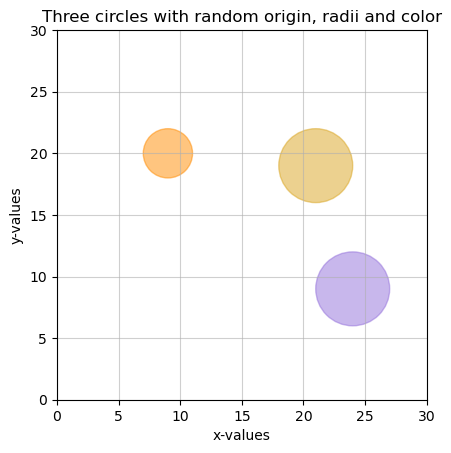

In [22]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse
from math import pi, sqrt
import random

class AstroEllipse(Ellipse):
    """Converts astronomical ellipse atributes to mathmatical elliple attributes"""
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # Save these as attributes so the rest of the class can see them.
        self.xc = xc
        self.yc = yc
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.pa = position_angle
        
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)
        angle_mpl = position_angle
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
        """A function that calculates the area of an ellipse using the objects parameters"""
        a = pi*self.semi_major*self.semi_minor
        return a   
    def perimeter(self):
        """A function that calculates the perimeter using the objects parameters"""
        a, b = self.semi_major, self.semi_minor
        p = pi*(3*(a+b) - sqrt((3*a+b)*(a+3*b)))
        return p
    def __str__(self):
        """A function that returns the objects parameters as a string"""
        s = (f"Ellipse parameters \n"  #\n to start next part on a new line.
        "--------------------\n"
        f"The center: ({self.xc}, {self.yc})\n"
        f"The semi major axis: {self.semi_major}\n"
        f"The semi minor axis: {self.semi_minor}\n" 
        f"The position angle: {self.pa}\n")
        return s

class MyCircle(AstroEllipse):
    """Use the AstroEllipse class to return circles"""
    def __init__(self, xc, yc, radius, **args):
        self.radius = radius  # Store the radius
        super().__init__(xc, yc, radius, radius, 0, **args)  # Position angle is required, so it is set to 0 (a circle is  fully symmetric, rotation does nothing to it).
    def __str__(self):  # Redefine __str__() for MyCircle, otherwise it will print the ellipse paramaters as MyCircle inherits form AstroEllipse.
        """A function that returns the objects parameters as a string"""
        s = (f"Circle parameters \n"
        "--------------------\n"
        f"The center: ({self.xc}, {self.yc})\n"
        f"The radius: {self.radius}\n")
        return s

fig, ax = plt.subplots()  # Plot the figure and the axes

# Randomize origin and radius for all three circles and add them to axis.

colors = ['mediumpurple', 'darkturquoise', 'lightskyblue', 'maroon', 'goldenrod', 'darkorange', 'yellowgreen']  # List with colors to choose.
c_random = random.sample(colors, 3)  # Picks three unqique random colors from the list.

for i in range(0, 3):  # Create new numbers for each of the three circles.
    xc = np.random.randint(5, 25)
    yc = np.random.randint(5, 25)
    radius = np.random.randint(1, 5)
    circle = MyCircle(xc, yc, radius, color=c_random[i], alpha=0.5)  # Create circle
    ax.add_patch(circle)  # Add circle to the figure

# Set axis limits so the circles are ensured to stay in the view.

ax.set_xlim(0, 30)
ax.set_ylim(0, 30)
ax.set_aspect('equal') # Keep circles circular, not squashed

# Plot labels and grid

plt.title("Three circles with random origin, radii and color")
plt.xlabel("x-values")
plt.ylabel("y-values")
plt.grid(alpha=0.6)
plt.show()

In [8]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

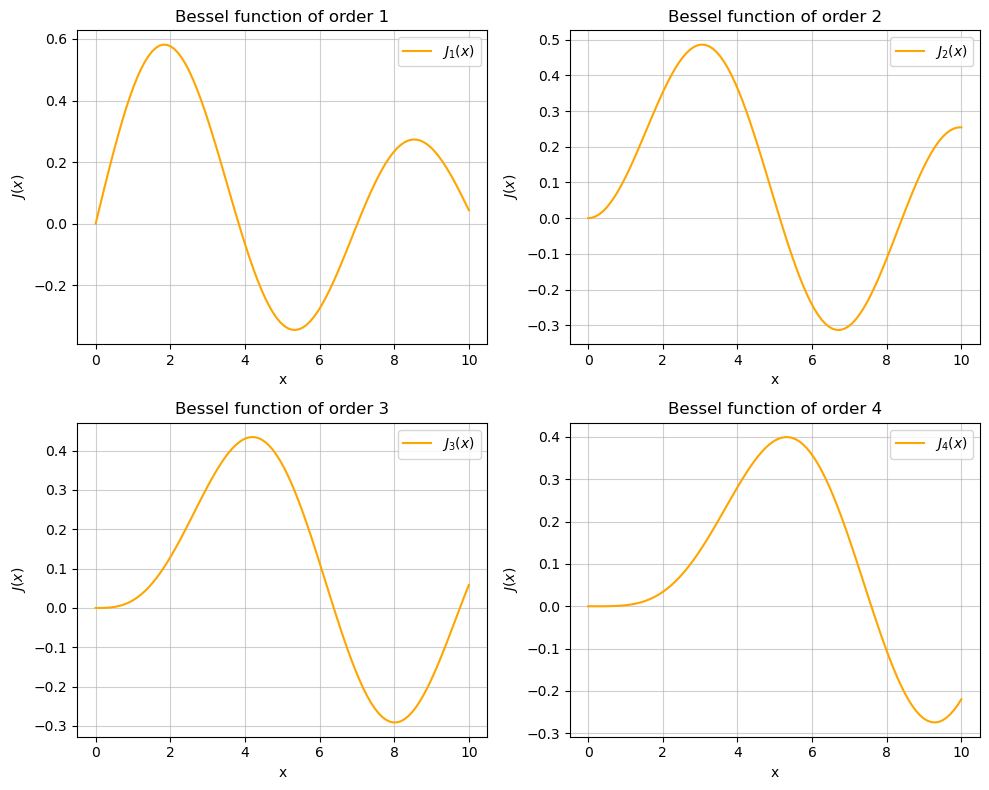

In [9]:
from scipy.special import jv
import numpy as np
from matplotlib.pyplot import figure, show

x = np.linspace(0, 10, 100)  # Create interval array of 100 numbers between 0 and 10, evenly spaced.
orders = [1, 2, 3, 4]  # The four orders

fig = figure(figsize=(10, 8))  # Create a figure

# Loop through the orders to plot all 4.

for i, a in enumerate(orders):  #Returns the index and value of orders
    #ax = i
    frame = fig.add_subplot(2, 2, i+1)  # Makes mosaic of 2x2 figures and adds each plot to one figure accordingly. 
    y = jv(a, x)  # Calculate Bessel function

    # Plot details.
    
    frame.plot(x, y, color='orange', label=f"$J_{a}(x)$")
    frame.set_title(f"Bessel function of order {a}")
    frame.set_xlabel("x")
    frame.set_ylabel("$J(x)$")
    frame.legend()
    frame.grid(linestyle='-', alpha=0.6)  # Set linestyle and transparency.

fig.tight_layout()  # Leaves space between the plots to avoid labelling overlaps.
fig.savefig("bessel.png", transparent=True)  # Save the figure as bessel.png.

show()

The figure:

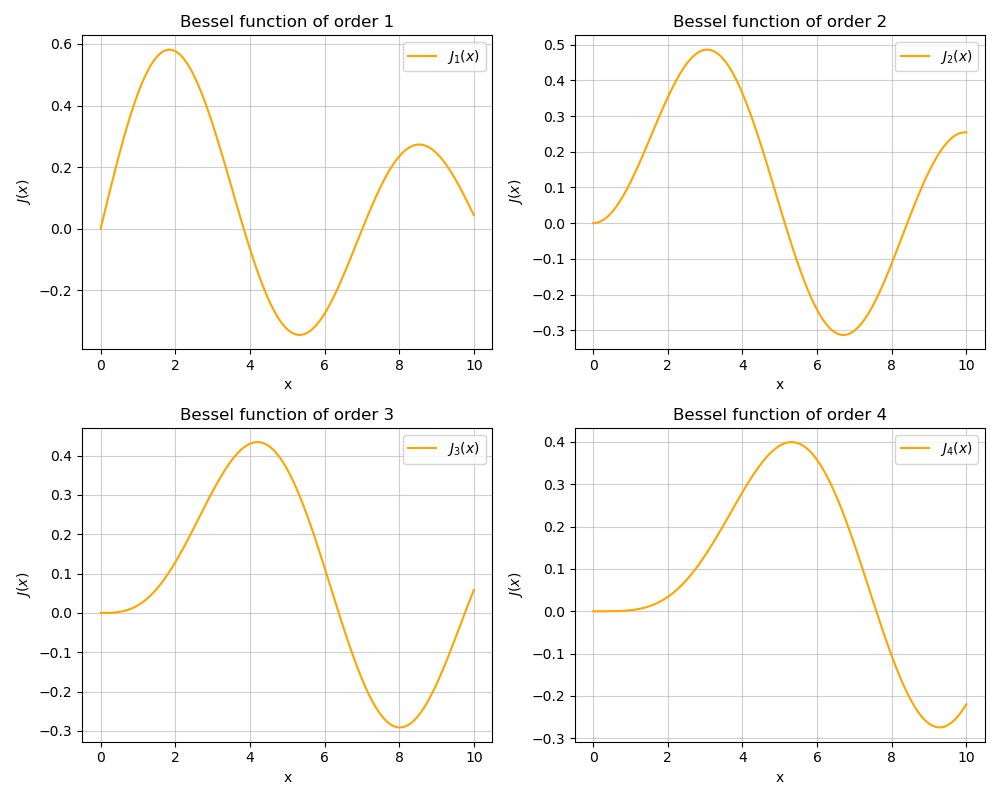

In [10]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

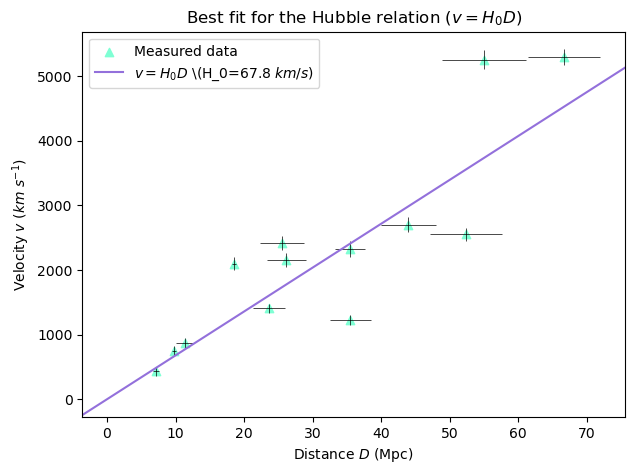

In [11]:
from matplotlib.pyplot import show

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

# Unpack data by specifying the column, then getting every 4th item (as there are 4 columns).

distance = data[0::4]
velocity = data[1::4]
distance_err = data[2::4]
velocity_err = data[3::4]

# Create plot

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(distance, velocity, marker='^', color='aquamarine', label='Measured data')  # Plot data points on the axis
ax.errorbar(distance, velocity, xerr=distance_err, yerr=velocity_err, ecolor='black', ls='none', linewidth=0.5)  # Plot errorbars, ls='none' makes sure there is no line connecting the points.
ax.axline((0, 0), slope=67.8, color='mediumpurple', label=r'$v=H_0D$ \(H_0=67.8 $km/s$)')  # Add Hubble relation (v=H_0D) as line through the origin.

ax.set_title(r"Best fit for the Hubble relation ($v=H_0D$)")
ax.set_xlabel(r"Distance $D$ (Mpc)")
ax.set_ylabel(r"Velocity $v$ ($km$ $s^{-1}$)")
ax.legend()
show()

In [12]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
